In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data = pd.read_csv("aviation-accident-dataset.csv")
data.head()

,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Latitude,Longitude,Airport_Code,Airport_Name,...,Air_Carrier,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_Phase_Of_Flight,Report_Status,Publication_Date,geo_point
0,20160425X54913,Accident,ERA16FA170,2016-04-25,"Pompano Beach, FL",United States,26.238055,-80.091666,PMP,POMPANO BEACH AIRPARK,...,NaN,NaN,3.0,NaN,NaN,VMC,TAKEOFF,Preliminary,2016-05-03,"26.238055, -80.091666"
1,20160418X14053,Accident,CEN16LA153,2016-04-01,"Addison, TX",United States,32.968611,-96.836389,ADS,Addison,...,NaN,NaN,NaN,NaN,1.0,VMC,LANDING,Factual,2016-11-14,"32.968611, -96.836389"
2,20151208X01729,Accident,CEN16LA058,2015-12-07,"Angleton, TX",United States,29.108611,-95.461944,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,VMC,MANEUVERING,Factual,2016-11-07,"29.108611, -95.461944"
3,20151204X00005,Accident,ERA16LA059,2015-12-03,"Raeford, NC",United States,35.019723,-79.191111,5W4,P K Airport,...,NaN,NaN,NaN,NaN,1.0,VMC,DESCENT,Factual,2016-11-02,"35.019723, -79.191111"
4,20151110X21143,Accident,CEN16LA035,2015-11-03,"Escanaba, MI",United States,45.722778,-87.093611,ESC,Delta County Airport,...,NaN,NaN,NaN,1.0,NaN,VMC,APPROACH,Preliminary,2015-11-18,"45.722778, -87.093611"


## ACCIDENT RISK SCORING MODEL

In [8]:
# Create total injury count
data["Total_Injuries"] = (
    data["Total_Fatal_Injuries"].fillna(0) +
    data["Total_Serious_Injuries"].fillna(0) +
    data["Total_Minor_Injuries"].fillna(0)
)

# Assign damage score
damage_score = {"Minor": 1, "Substantial": 2, "Destroyed": 3}
data["Damage_Score"] = data["Aircraft_Damage"].map(damage_score)

# Risk Index
data["Risk_Index"] = data["Total_Injuries"] + data["Damage_Score"].fillna(0)

# View highest risk accidents
data.sort_values("Risk_Index", ascending=False).head()


,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Latitude,Longitude,Airport_Code,Airport_Name,...,Total_Minor_Injuries,Total_Uninjured,Weather Condition,Broad_Phase_Of_Flight,Report_Status,Publication_Date,geo_point,Total_Injuries,Damage_Score,Risk_Index
32306,20001212X21426,Incident,DCA00WA074,2000-07-23,"MONTREAL, Canada",Canada,NaN,NaN,NaN,NaN,...,380.0,NaN,IMC,NaN,Foreign,NaN,NaN,380.0,1.0,381.0
16999,20020124X00116,Accident,DCA97WA007B,1996-11-12,"New Delhi, India",India,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Foreign,2002-01-24,NaN,349.0,NaN,349.0
19100,20020124X00116,Accident,DCA97WA007A,1996-11-12,"New Delhi, India",India,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Foreign,2002-01-24,NaN,349.0,NaN,349.0
35928,20140718X92314,Accident,DCA14RA127,2014-07-17,"Hrabove, Ukraine",Ukraine,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Foreign,NaN,NaN,295.0,3.0,298.0
55322,20001213X28786,Accident,DCA89MA063,1989-07-19,"SIOUX CITY, IA",United States,NaN,NaN,SUX,SIOUX GATEWAY,...,125.0,13.0,VMC,CRUISE,Probable Cause,1992-10-08,NaN,283.0,3.0,286.0


##### Explanation

###### More injuries = higher risk
###### Destroyed aircraft = higher risk
###### Combined into one numeric risk value

## WEATHER IMPACT SEVERITY ANALYZER

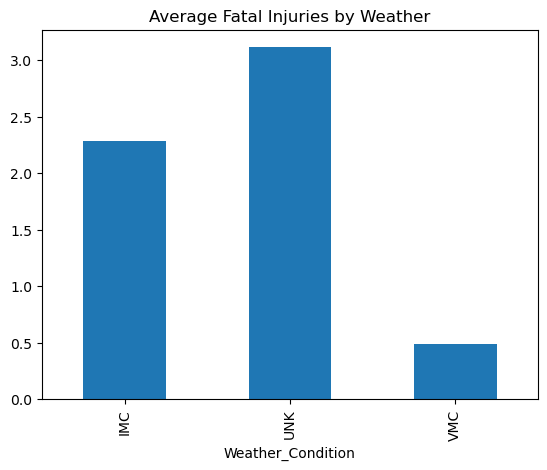

In [12]:
weather_severity = data.groupby("Weather_Condition")["Total_Fatal_Injuries"].mean()

weather_severity.plot(kind="bar")
plt.title("Average Fatal Injuries by Weather")
plt.show()

##### Explanation

###### Groups accidents by weather and calculates average fatalities.

## PHASE OF FLIGHT DANGER RANKING

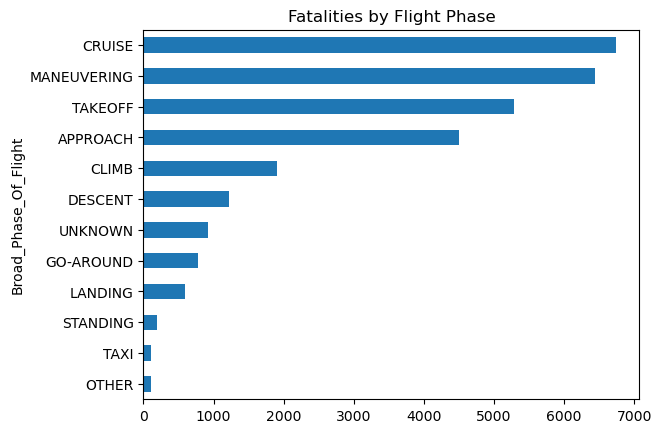

In [14]:
phase_danger = data.groupby("Broad_Phase_Of_Flight")["Total_Fatal_Injuries"].sum()

phase_danger.sort_values().plot(kind="barh")
plt.title("Fatalities by Flight Phase")
plt.show()


##### Explanation

###### Counts total deaths for each flight phase.

## AIRCRAFT DAMAGE PREDICTION (ML Model)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df = data[["Weather_Condition", "Broad_Phase_Of_Flight", "Aircraft_Damage"]].dropna()

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Aircraft_Damage", axis=1)
y = df["Aircraft_Damage"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7746429325265602


##### Explanation

###### Machine learning predicts damage severity.

## GEOGRAPHIC ACCIDENT HOTSPOTS

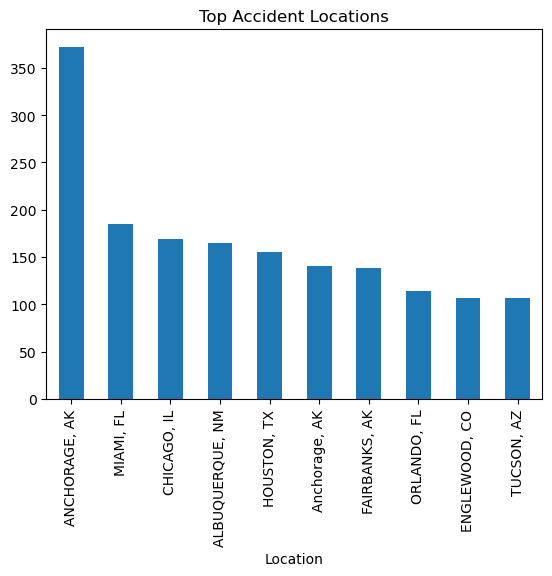

In [21]:
top_locations = data["Location"].value_counts().head(10)

top_locations.plot(kind="bar")
plt.title("Top Accident Locations")
plt.show()

##### Explanation

###### Counts accident per location.

## ENGINE CONFIGURATION SAFETY STUDY

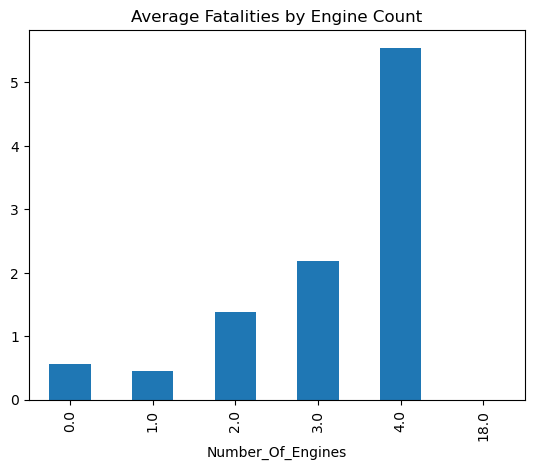

In [27]:
engine_risk = data.groupby("Number_Of_Engines")["Total_Fatal_Injuries"].mean()

engine_risk.plot(kind="bar")
plt.title("Average Fatalities by Engine Count")
plt.show()

##### Explanation

###### More engines = Less accidents.

## PURPOSE OF FLIGHT RISK COMPARISON

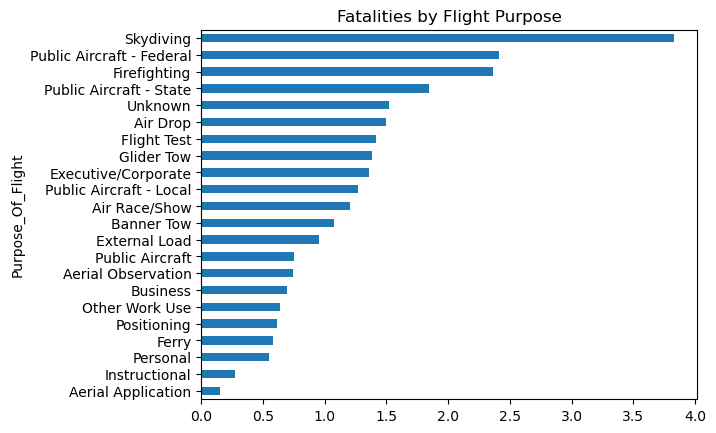

In [31]:
purpose_risk = data.groupby("Purpose_Of_Flight")["Total_Fatal_Injuries"].mean()

purpose_risk.sort_values().plot(kind="barh")
plt.title("Fatalities by Flight Purpose")
plt.show()

##### Explanation

###### Compares personal vs training vs commercial.

## INJURY OUTCOME PREDICTION (ML Classification)

In [39]:
from sklearn.linear_model import LogisticRegression

data["Fatal_Accident"] = np.where(data["Total_Fatal_Injuries"] > 0, 1, 0)
df = data[["Weather_Condition", "Broad_Phase_Of_Flight", "Fatal_Accident"]].dropna()

le = LabelEncoder()

for col in df.columns[:-1]:
    df[col] = le.fit_transform(df[col])

X = df.drop("Fatal_Accident", axis=1)
y = df["Fatal_Accident"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8198928424234098


##### Explanation

###### Predicts fatal vs non-fatal accident.

## ACCIDENT TREND OVER-TIME

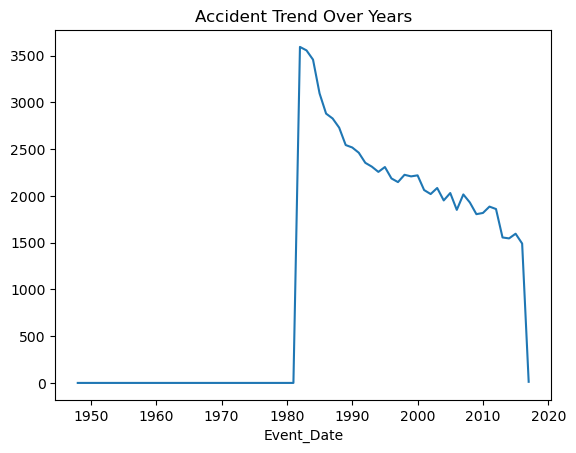

In [41]:
data["Event_Date"] = pd.to_datetime(data["Event_Date"], errors="coerce")
yearly = data["Event_Date"].dt.year.value_counts().sort_index()

yearly.plot()
plt.title("Accident Trend Over Years")
plt.show()

##### Explanation

###### Shows safety improvement or decline over time.

## SURVIVAL PROBABILITY MODEL

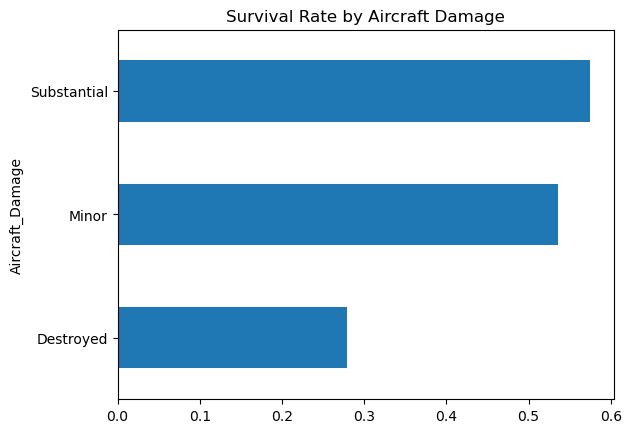

In [44]:
data["Survived"] = np.where(data["Total_Fatal_Injuries"] == 0, 1, 0)

survival_rate = data.groupby("Aircraft_Damage")["Survived"].mean()

survival_rate.plot(kind="barh")
plt.title("Survival Rate by Aircraft Damage")
plt.show()

##### Explanation

###### Shows survival likelihood for each damage type.

## MANUFACTURER SAFETY BENCHMARK

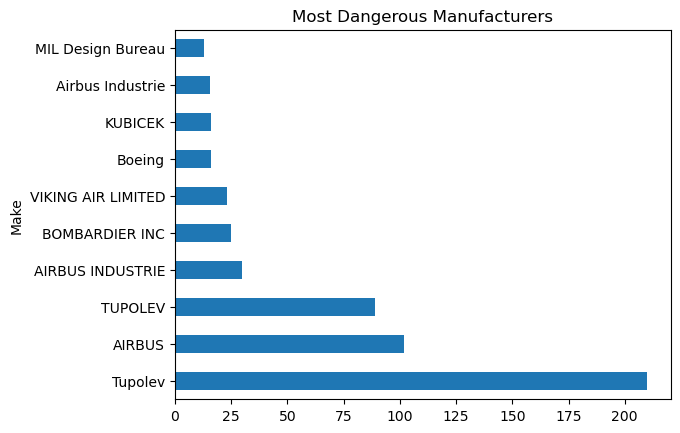

In [51]:
manufacturer_risk = data.groupby("Make")["Total_Fatal_Injuries"].mean().sort_values(ascending=False).head(10)

manufacturer_risk.plot(kind="barh")
plt.title("Most Dangerous Manufacturers")
plt.show()

##### Explanation

###### Compares aircraft brands by average fatalities.

## MULTI-FACTOR FAILURE ANALYSIS

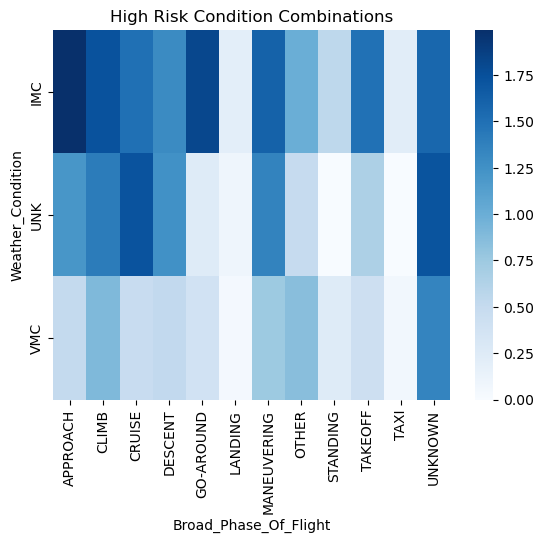

In [76]:
pattern = data.groupby(
    ["Weather_Condition", "Broad_Phase_Of_Flight"]
)["Total_Fatal_Injuries"].mean().unstack()

sns.heatmap(pattern, cmap="Blues")
plt.title("High Risk Condition Combinations")
plt.show()

##### Explanation

###### Heatmap shows dangerous combinations.